# Expressing Grouped-Query Attention

This notebook writes causal grouped-query attention as a morphism and draws it as a neural circuit diagram. The query heads are divided into groups, and the heads of one group share one key head and one value head, as they do in Mixtral-8x7B. The last cell writes the attention to a page.

*Written by Claude Opus 5.5 (1M context) at reasoning effort 40, 2026-09-27.*

In [1]:
import dataclasses

import advanced_axis_dynamics.algebra.slide_causal_reads_backwards as slide_causal_reads_backwards
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.website.tutorial.express_attention as express_attention
import notebooks.website.tutorial.tutorial_pages as tutorial_pages
import notebooks.website.website_output as website_output

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE,
    dark_mode=notebook_diagrams.ColorMode.LIGHT,
    advanced_display=notebook_diagrams.AdvancedDisplay.LEGEND,
    operator_explanations=express_attention.OPERATOR_EXPLANATIONS,
    operator_references=express_attention.OPERATOR_REFERENCES,
    operator_roles=express_attention.GROUPED_QUERY_ROLES,
    reindexing_explanations=express_attention.REINDEXING_EXPLANATIONS,
    title='Grouped-Query Attention')
PAGE = dataclasses.replace(
    DIAGRAMS, mode=notebook_diagrams.DiagramMode.HTML,
    advanced_display=notebook_diagrams.AdvancedDisplay.INTERACTIVE,
    page_directory=website_output.TUTORIAL_PAGES)

MODEL = express_attention.grouped_query_attention()
DISPLAYED = slide_causal_reads_backwards.slide_causal_reads_backwards(MODEL)

## Grouping the query heads

$W^{Q}$ projects the state of each token into $|h'|$ groups of $|g|$ query heads, so the queries carry the two axes $h'$ and $g$. $W^{K}$ and $W^{V}$ project the state into one key head and one value head for each group, so the keys and the values carry $h'$ and no $g$. The dot product reads the key head of the group of each query head, so every query head of a group scores against the same key head, and the weighted sum reads the values the same way. $W^{O}$ reads the groups, the heads within them and the channels together.

$$\mathrm{GQA}(z) = \sum_{i_{h'} \in h'} \sum_{i_{g} \in g} \mathrm{Attention}(z W^{Q}[i_{h'}, i_{g}], z W^{K}[i_{h'}], z W^{V}[i_{h'}])\, W^{O}[i_{h'}, i_{g}]$$

The released code of Mixtral-8x7B projects the queries onto 32 heads and repeats every key head and every value head four times, so that query head $i$ attends with key head $\lfloor i / 4 \rfloor$ ([`transformer_layers.py` L16-L19](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L16-L19), [L83-L84](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L83-L84), read on 2026-09-27). Integer division is not an affine map of the head index, and the map $|g|\, i_{h'} + i_{g}$ from a group and a head within it to a query head is affine. The expression therefore writes the grouping into $W^{Q}$, whose weight holds the same entries grouped the same way. No view regroups the heads, and no key or value is repeated.

## Grouped-query attention between multi-head and multi-query attention

Section 2.2 of [the paper that introduced grouped-query attention](https://arxiv.org/pdf/2305.13245v3) states that grouped-query attention with one group is multi-query attention, in which every query head shares one key head and one value head, and that grouped-query attention with one query head in each group is multi-head attention. The keys and the values of a token hold $|h'| |d|$ channels each, where the queries hold $|h'| |g| |d|$. The keys and the values of the earlier tokens that a model keeps while it generates are therefore $|g|$ times fewer than in multi-head attention with the same number of query heads.

The keys and the values are read through the causal mask of [Expressing Attention with Weights and a Residual Connection](AttentionWithWeightsAndResidual.ipynb), and the figure draws the model in the CausalSlide form, with the mask at the copy of the state and $W^{K}$ and $W^{V}$ running over the tokens and the slots.

Grouped-query attention in the CausalSlide form. The queries carry h' groups of g heads, and the keys and the values carry h' alone.


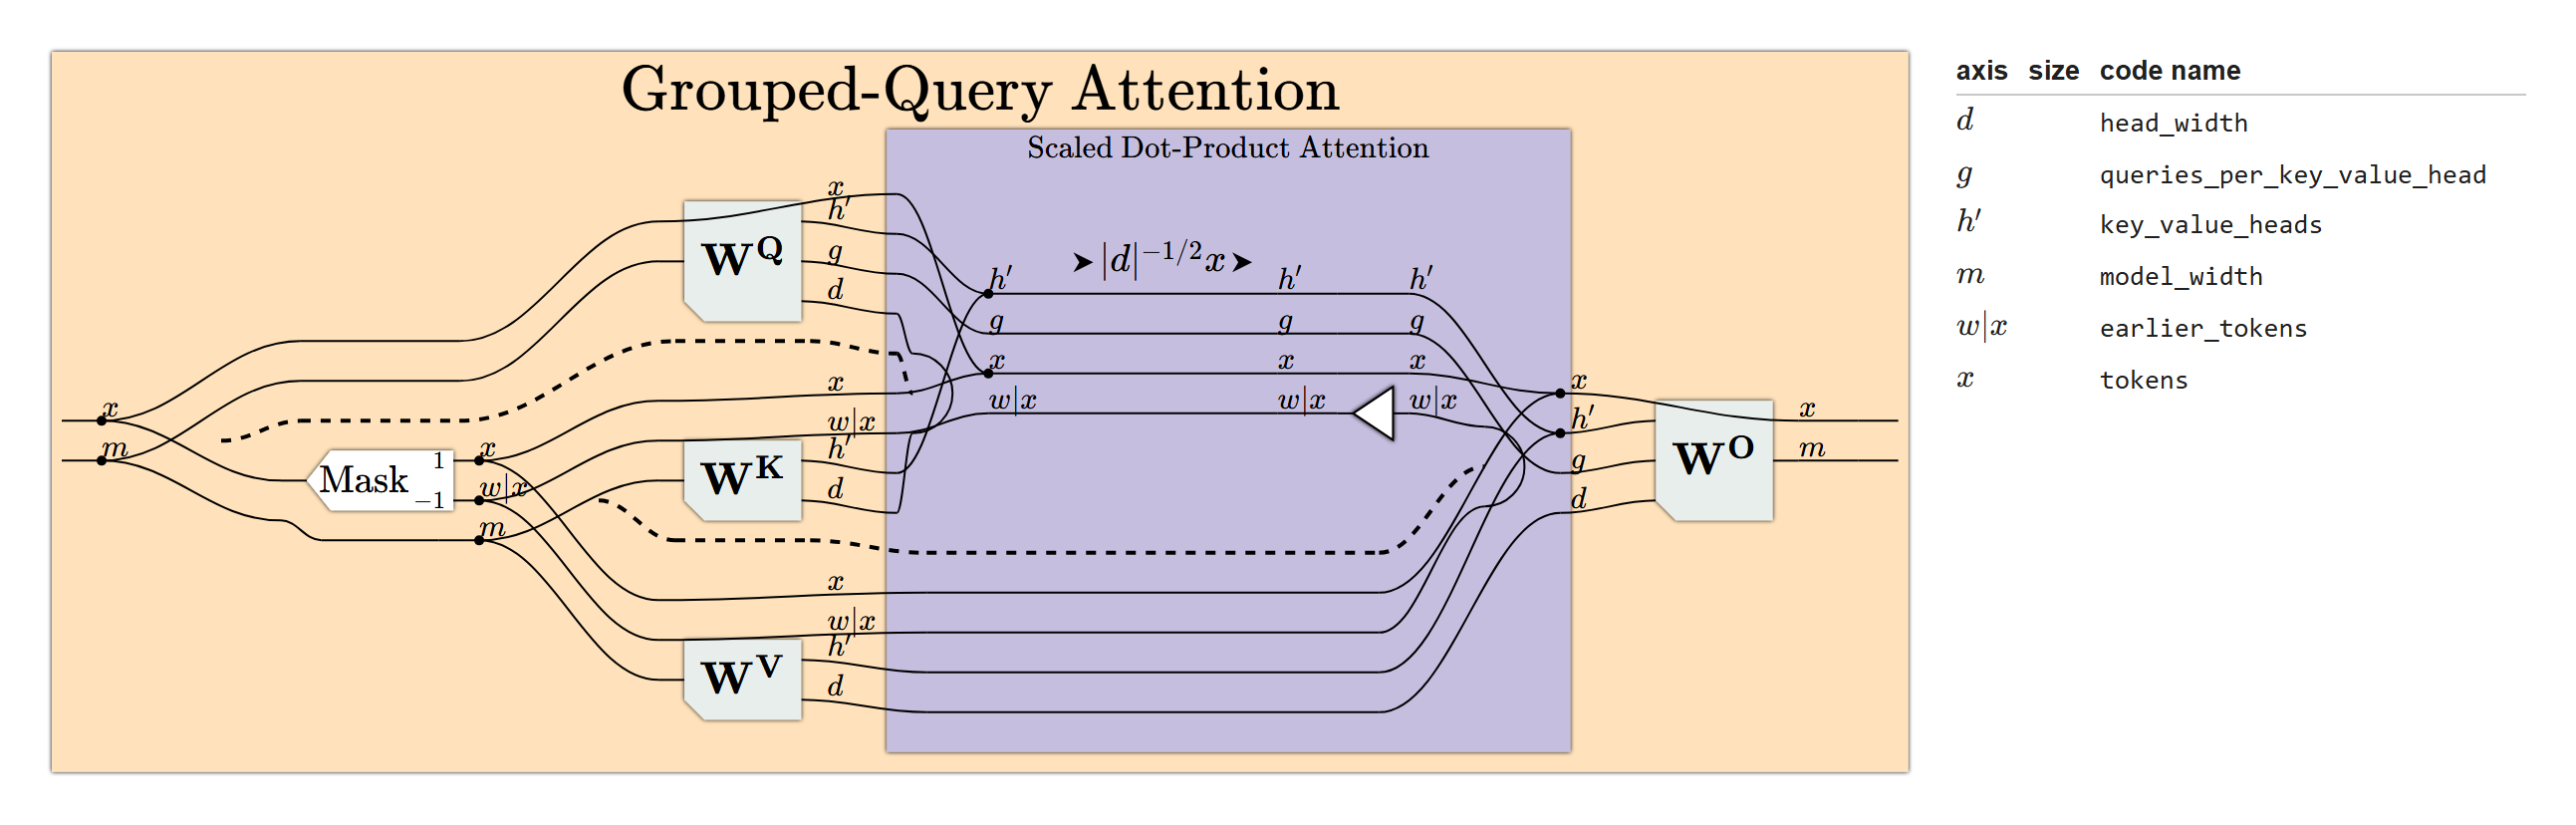

In [2]:
await notebook_diagrams.show_diagram(
    DISPLAYED,
    "Grouped-query attention in the CausalSlide form. The queries carry h' groups of g "
    "heads, and the keys and the values carry h' alone.",
    width=1500, settings=DIAGRAMS)

## The interactive page

The last cell writes the attention to `notebooks/website/output/tutorial/GroupedQueryAttention/index.html`, one file that opens with no server and no network. Resting the pointer on a block opens a box with its title, its formula and its description, resting it on a matrix opens the role of that matrix with the sources that state it, and resting it on the mask opens the formula of the view.

In [3]:
await notebook_diagrams.show_page_variants(
    tutorial_pages.grouped_query_attention_page(DISPLAYED, PAGE),
    'Grouped-query attention as one HTML file.',
    settings=PAGE, slug=tutorial_pages.GROUPED_QUERY_ATTENTION_SLUG,
    initial=tutorial_pages.FORWARD)

Grouped-query attention as one HTML file.


(written to notebooks/website/output/tutorial/GroupedQueryAttention/)
